# BAM 기반 LoRa 스펙트로그램 디노이징 (2^i 층수)

## 핵심 변경사항
- **층수**: 2^i (4, 8, 16, 32, 64)
- **구조**: 대칭 (input → 확장 → peak → 축소 → bottleneck)
- **학습**: 레이어별 수렴까지 학습 + 에폭당 loss 출력

## 구조 예시 (16층, input=2048, bottleneck=64)
```
Peak = input + (input - bottleneck) = 4032

전반 8층 (확장): 2048 → 2296 → ... → 4032
후반 8층 (축소): 4032 → ... → 560 → 64
```

In [1]:
import os, glob, math, sys, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.LoRa import LoRa, MultiBAM

np.random.seed(42)

# ===== LoRa 파라미터 =====
SF = 9
BW = 125_000
OSF = 8
FS = 1_000_000

N_sym = (2**SF) * OSF  # 4096
STFT_PARAMS = {
    'nperseg': 256,
    'noverlap': 128,
    'nfft': 512,
    'window': 'hann'
}

# ===== 학습 파라미터 =====
SNR_MIN = -10
SNR_MAX = 0
TRAIN_BATCH = 64

# ===== 2^i 층수 설정 =====
NUM_LAYERS = 16        # 2^4 = 16층 (4, 8, 16, 32, 64 중 선택)
BOTTLENECK = 64        # 병목 유닛 수
ETA = 1e-4             # 학습률

# 데이터 경로
DATA_DIR = "dataset_sf9_bw125k/clean_iq"

print(f"LoRa: SF={SF}, BW={BW/1000:.0f}kHz, FS={FS/1e6:.1f}MHz")
print(f"BAM: {NUM_LAYERS}층 (2^{int(np.log2(NUM_LAYERS))}), bottleneck={BOTTLENECK}, eta={ETA}")

LoRa: SF=9, BW=125kHz, FS=1.0MHz
BAM: 16층 (2^4), bottleneck=64, eta=0.0001


In [2]:
# ===== 2^i 층수 레이어 구조 생성 =====

def build_layers_2i(input_dim, num_layers, bottleneck):
    """
    2^i 층수, 선형 대칭 구조
    
    Args:
        input_dim: 입력 차원 (예: 2048)
        num_layers: 층수 (2, 4, 8, 16, 32, 64)
        bottleneck: 병목 유닛 (예: 64)
    
    구조: input → (확장) → peak → (축소) → bottleneck
    """
    if num_layers < 2:
        return [input_dim, bottleneck]
    
    half = num_layers // 2
    
    # Peak: 대칭을 위해 input + (input - bottleneck)
    peak = input_dim + (input_dim - bottleneck)
    
    layers = [input_dim]
    
    # 전반부: input → peak (선형 확장)
    step_up = (peak - input_dim) / half
    for i in range(1, half + 1):
        layers.append(int(input_dim + step_up * i))
    
    # 후반부: peak → bottleneck (선형 축소)
    step_down = (peak - bottleneck) / half
    for i in range(1, half):
        layers.append(int(peak - step_down * i))
    
    layers.append(bottleneck)
    
    return layers


def print_layers(layers):
    """레이어 구조 출력"""
    print(f"\n📐 레이어 구조 ({len(layers)-1}층):")
    print(f"   입력: {layers[0]}")
    print(f"   Peak: {max(layers)}")
    print(f"   Bottleneck: {layers[-1]}")
    print(f"   전체: {layers[:3]} ... {layers[-3:]}")
    
    # 시각화
    max_dim = max(layers)
    print(f"\n   구조 시각화:")
    for i, dim in enumerate(layers):
        bar_len = int(30 * dim / max_dim)
        bar = '█' * bar_len
        print(f"   [{i:2d}] {dim:5d} {bar}")


# 테스트
test_layers = build_layers_2i(2048, 16, 64)
print_layers(test_layers)


📐 레이어 구조 (16층):
   입력: 2048
   Peak: 4032
   Bottleneck: 64
   전체: [2048, 2296, 2544] ... [1056, 560, 64]

   구조 시각화:
   [ 0]  2048 ███████████████
   [ 1]  2296 █████████████████
   [ 2]  2544 ██████████████████
   [ 3]  2792 ████████████████████
   [ 4]  3040 ██████████████████████
   [ 5]  3288 ████████████████████████
   [ 6]  3536 ██████████████████████████
   [ 7]  3784 ████████████████████████████
   [ 8]  4032 ██████████████████████████████
   [ 9]  3536 ██████████████████████████
   [10]  3040 ██████████████████████
   [11]  2544 ██████████████████
   [12]  2048 ███████████████
   [13]  1552 ███████████
   [14]  1056 ███████
   [15]   560 ████
   [16]    64 


In [3]:
# ===== 스펙트로그램 처리 함수 =====

def stft_bw_crop(iq, fs=FS, bw=BW, params=STFT_PARAMS):
    """STFT 후 BW 범위만 crop"""
    f, t, Z = stft(iq, fs=fs, window=params['window'], nperseg=params['nperseg'],
                   noverlap=params['noverlap'], nfft=params['nfft'],
                   boundary=None, padded=False, return_onesided=False)
    
    f_shift = np.fft.fftshift(f)
    Z_shift = np.fft.fftshift(Z, axes=0)
    
    mask = (f_shift >= -bw/2) & (f_shift < bw/2)
    f_crop = f_shift[mask]
    Z_crop = Z_shift[mask, :]
    
    mag = np.abs(Z_crop)
    mag_db = 20 * np.log10(mag + 1e-10)
    
    return mag_db, f_crop, {'shape': mag_db.shape, 'mask': mask}


def flatten_spec(spec_2d):
    """2D → 1D flatten + 2의 거듭제곱 패딩"""
    vec = spec_2d.flatten()
    L = len(vec)
    pow2 = 1 << math.ceil(math.log2(max(L, 1)))
    pad_len = pow2 - L
    if pad_len > 0:
        vec = np.pad(vec, (0, pad_len))
    return vec, {'orig_len': L, 'pad_len': pad_len, 'shape': spec_2d.shape}


def unflatten_spec(vec, meta):
    """1D → 2D 복원"""
    return vec[:meta['orig_len']].reshape(meta['shape'])


def zscore(x, mean, std):
    return (x - mean) / (std + 1e-8)


def zscore_inv(xn, mean, std):
    return xn * (std + 1e-8) + mean


print("✅ 스펙트로그램 처리 함수 정의 완료")

✅ 스펙트로그램 처리 함수 정의 완료


In [4]:
# ===== 데이터 로드 =====

iq_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.npy')))

if len(iq_files) == 0:
    print(f"⚠️ 데이터 없음! generate.ipynb를 먼저 실행하세요.")
    print(f"   경로: {DATA_DIR}")
    raise FileNotFoundError(f"No data in {DATA_DIR}")

clean_iq = np.array([np.load(f) for f in iq_files])
print(f'✅ 데이터 로드: {clean_iq.shape}')

# 입력 차원 확인
mag_ex, f_ex, meta_ex = stft_bw_crop(clean_iq[0])
flat_ex, pad_meta_ex = flatten_spec(mag_ex)
INPUT_DIM = len(flat_ex)

print(f'\n📊 스펙트로그램:')
print(f'   Shape: {mag_ex.shape} (freq × time)')
print(f'   Flatten: {pad_meta_ex["orig_len"]} → 패딩 후: {INPUT_DIM}')

# Z-score 통계
print('\n⏳ Z-score 통계 계산 중...')
flats = []
for x in clean_iq:
    mag, _, _ = stft_bw_crop(x)
    fvec, _ = flatten_spec(mag)
    flats.append(fvec)
flats = np.stack(flats)
global_mean, global_std = flats.mean(axis=0), flats.std(axis=0)
print(f'✅ 완료')

✅ 데이터 로드: (512, 4096)

📊 스펙트로그램:
   Shape: (64, 31) (freq × time)
   Flatten: 1984 → 패딩 후: 2048

⏳ Z-score 통계 계산 중...
✅ 완료


In [5]:
# ===== 레이어 구조 생성 =====

layers = build_layers_2i(INPUT_DIM, NUM_LAYERS, BOTTLENECK)
print_layers(layers)

# 모델 생성
print(f"\n🧠 MultiBAM 모델 생성 (eta={ETA})")
model = MultiBAM(layers, eta=ETA)
print(f"   레이어 수: {len(model.bams)}")


📐 레이어 구조 (16층):
   입력: 2048
   Peak: 4032
   Bottleneck: 64
   전체: [2048, 2296, 2544] ... [1056, 560, 64]

   구조 시각화:
   [ 0]  2048 ███████████████
   [ 1]  2296 █████████████████
   [ 2]  2544 ██████████████████
   [ 3]  2792 ████████████████████
   [ 4]  3040 ██████████████████████
   [ 5]  3288 ████████████████████████
   [ 6]  3536 ██████████████████████████
   [ 7]  3784 ████████████████████████████
   [ 8]  4032 ██████████████████████████████
   [ 9]  3536 ██████████████████████████
   [10]  3040 ██████████████████████
   [11]  2544 ██████████████████
   [12]  2048 ███████████████
   [13]  1552 ███████████
   [14]  1056 ███████
   [15]   560 ████
   [16]    64 

🧠 MultiBAM 모델 생성 (eta=0.0001)
   레이어 수: 16


In [6]:
# ===== LoRa 인스턴스 (AWGN용) =====

lora = LoRa(sf=SF, bw=BW, OSF=OSF)

def get_clean_batch(batch_size):
    """클린 스펙트로그램 배치"""
    idx = np.random.randint(0, len(clean_iq), size=batch_size)
    batch = []
    for i in idx:
        mag, _, _ = stft_bw_crop(clean_iq[i])
        fvec, _ = flatten_spec(mag)
        batch.append(zscore(fvec, global_mean, global_std))
    return np.stack(batch).astype(np.float32)


print("✅ 유틸리티 함수 정의 완료")

✅ 유틸리티 함수 정의 완료


In [7]:
# ===== 학습: 레이어별 수렴까지 =====

def train_layer_until_converge(bam, get_data_fn, max_epochs=500, patience=50, tol=1e-6, verbose=True):
    """
    단일 BAM 레이어를 수렴까지 학습
    
    Args:
        bam: BAM 레이어 (model.bams[i])
        get_data_fn: 데이터 가져오는 함수 (현재 레이어 입력 반환)
        max_epochs: 최대 에폭
        patience: Early stopping patience
        tol: 수렴 판정 tolerance
    
    Returns:
        losses: 에폭별 loss 리스트
    """
    losses = []
    best_loss = np.inf
    no_improve = 0
    
    for epoch in range(max_epochs):
        # 데이터 가져오기
        xb = get_data_fn()
        
        # 학습
        bam.train(xb)
        
        # Loss 계산: 재구성 오차
        compressed = bam.compress(xb)
        reconstructed = bam.decompress(compressed)
        loss = float(np.mean((xb - reconstructed) ** 2))
        losses.append(loss)
        
        # 발산 체크
        if np.isnan(loss) or loss > 1e6:
            print(f"      ⚠️ 발산! epoch={epoch}, loss={loss}")
            break
        
        # Early stopping
        if loss + tol < best_loss:
            best_loss = loss
            no_improve = 0
        else:
            no_improve += 1
        
        # 진행 출력
        if verbose and (epoch + 1) % 50 == 0:
            print(f"      epoch {epoch+1:4d}: loss={loss:.6f}, best={best_loss:.6f}")
        
        # 수렴 판정
        if no_improve >= patience:
            if verbose:
                print(f"      ✓ 수렴! epoch={epoch+1}, loss={best_loss:.6f}")
            break
    
    return losses


def train_multibam_layerwise(model, batch_size=64, max_epochs=500, patience=50, verbose=True):
    """
    MultiBAM 레이어별 순차 학습
    
    각 레이어를 수렴할 때까지 학습한 후 다음 레이어로 진행
    """
    all_losses = {}
    
    print(f"\n{'='*60}")
    print(f"🚀 레이어별 순차 학습 시작")
    print(f"   총 {len(model.bams)}개 레이어")
    print(f"{'='*60}")
    
    for layer_idx, bam in enumerate(model.bams):
        print(f"\n📚 레이어 {layer_idx+1}/{len(model.bams)}: {bam.input_dim} → {bam.output_dim}")
        
        # 현재 레이어의 입력 데이터 생성 함수
        def get_layer_input():
            xb = get_clean_batch(batch_size)
            # 이전 레이어들을 통과시켜서 현재 레이어 입력 생성
            current = xb
            for prev_bam in model.bams[:layer_idx]:
                current = prev_bam.compress(current)
            return current
        
        # 현재 레이어 학습
        t0 = time.time()
        layer_losses = train_layer_until_converge(
            bam, get_layer_input, 
            max_epochs=max_epochs, 
            patience=patience,
            verbose=verbose
        )
        train_time = time.time() - t0
        
        all_losses[layer_idx] = layer_losses
        print(f"   완료: {len(layer_losses)} epochs, {train_time:.1f}초")
    
    print(f"\n{'='*60}")
    print(f"✅ 전체 학습 완료!")
    print(f"{'='*60}")
    
    return all_losses


print("✅ 학습 함수 정의 완료")

✅ 학습 함수 정의 완료


In [8]:
# ===== 학습 실행 =====

t0 = time.time()
all_losses = train_multibam_layerwise(
    model, 
    batch_size=TRAIN_BATCH,
    max_epochs=500,
    patience=50,
    verbose=True
)
total_time = time.time() - t0
print(f"\n⏱️ 총 학습 시간: {total_time:.1f}초")


🚀 레이어별 순차 학습 시작
   총 16개 레이어

📚 레이어 1/16: 2048 → 2296
      epoch   50: loss=1.890545, best=1.665433
      ✓ 수렴! epoch=51, loss=1.665433
   완료: 51 epochs, 83.6초

📚 레이어 2/16: 2296 → 2544
      epoch   50: loss=1.627243, best=1.463257
      ✓ 수렴! epoch=51, loss=1.463257
   완료: 51 epochs, 108.3초

📚 레이어 3/16: 2544 → 2792
      epoch   50: loss=1.520981, best=1.314133
      ✓ 수렴! epoch=51, loss=1.314133
   완료: 51 epochs, 136.8초

📚 레이어 4/16: 2792 → 3040
      epoch   50: loss=1.327631, best=1.186300
      ✓ 수렴! epoch=51, loss=1.186300
   완료: 51 epochs, 164.8초

📚 레이어 5/16: 3040 → 3288
      epoch   50: loss=1.229868, best=1.112765
      ✓ 수렴! epoch=51, loss=1.112765
   완료: 51 epochs, 205.9초

📚 레이어 6/16: 3288 → 3536
      epoch   50: loss=1.145361, best=1.001494
      ✓ 수렴! epoch=51, loss=1.001494
   완료: 51 epochs, 235.5초

📚 레이어 7/16: 3536 → 3784
      epoch   50: loss=1.007937, best=0.950650
      ✓ 수렴! epoch=51, loss=0.950650
   완료: 51 epochs, 278.6초

📚 레이어 8/16: 3784 → 4032
      epoch   5

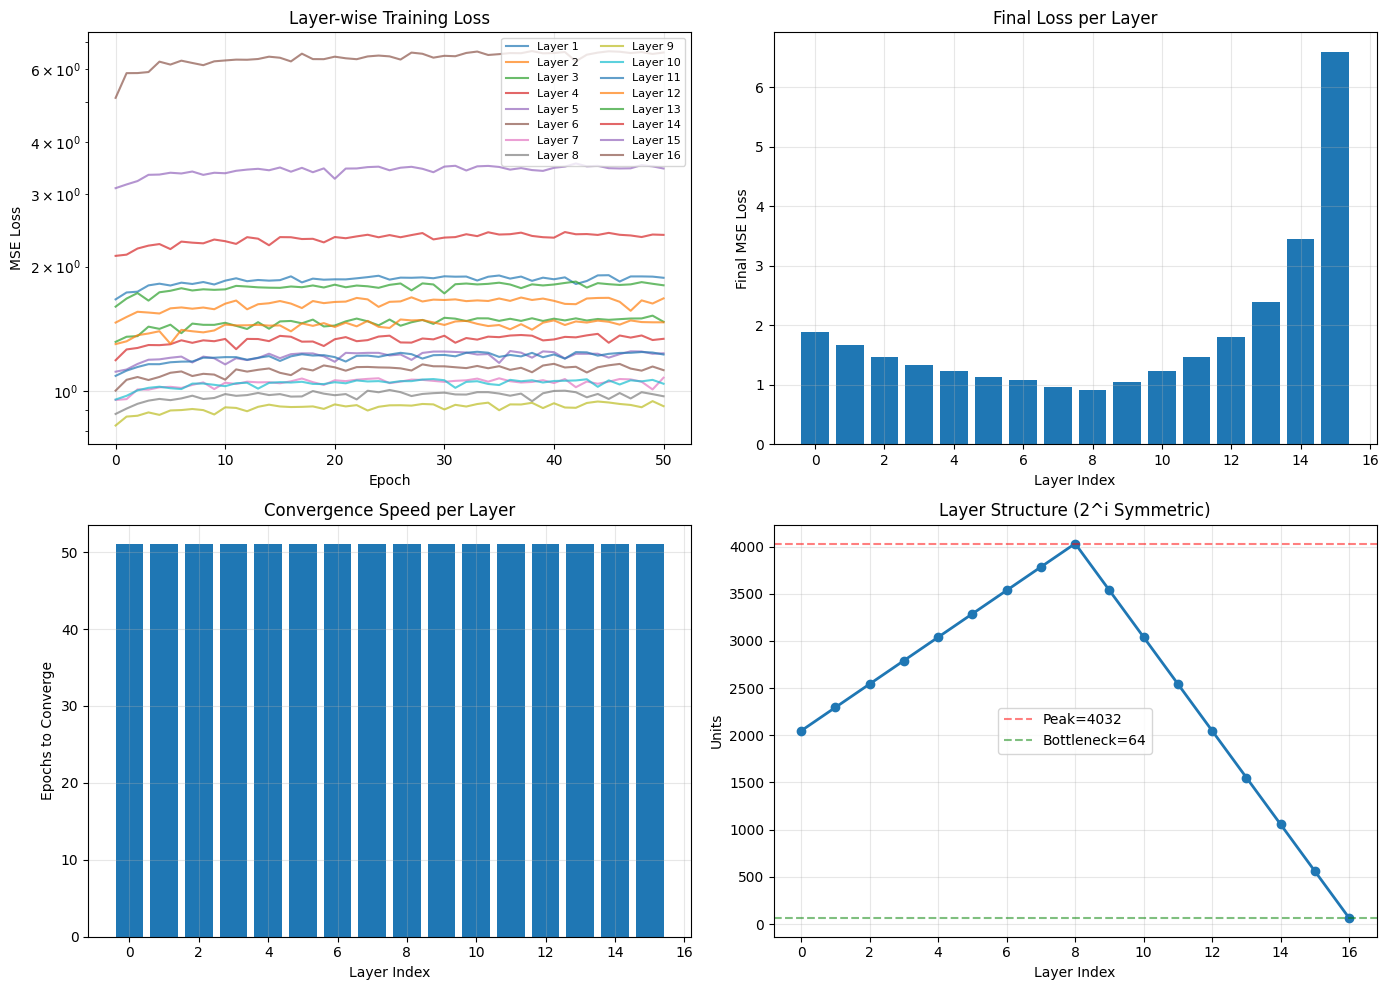

In [9]:
# ===== 학습 곡선 시각화 =====

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 각 레이어별 학습 곡선
ax = axes[0, 0]
for layer_idx, losses in all_losses.items():
    ax.plot(losses, label=f'Layer {layer_idx+1}', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Layer-wise Training Loss')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# 2. 레이어별 최종 loss
ax = axes[0, 1]
final_losses = [losses[-1] if losses else 0 for losses in all_losses.values()]
ax.bar(range(len(final_losses)), final_losses)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Final MSE Loss')
ax.set_title('Final Loss per Layer')
ax.grid(True, alpha=0.3)

# 3. 레이어별 수렴 에폭
ax = axes[1, 0]
converge_epochs = [len(losses) for losses in all_losses.values()]
ax.bar(range(len(converge_epochs)), converge_epochs)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Epochs to Converge')
ax.set_title('Convergence Speed per Layer')
ax.grid(True, alpha=0.3)

# 4. 레이어 크기
ax = axes[1, 1]
ax.plot(layers, 'o-', linewidth=2, markersize=6)
ax.axhline(y=max(layers), color='r', linestyle='--', alpha=0.5, label=f'Peak={max(layers)}')
ax.axhline(y=BOTTLENECK, color='g', linestyle='--', alpha=0.5, label=f'Bottleneck={BOTTLENECK}')
ax.set_xlabel('Layer Index')
ax.set_ylabel('Units')
ax.set_title('Layer Structure (2^i Symmetric)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ===== 디노이징 함수 =====

def denoise_spectrogram(noisy_iq, model, global_mean, global_std):
    """노이즈 IQ → BAM 디노이징 → 스펙트로그램"""
    mag_noisy, f_crop, meta = stft_bw_crop(noisy_iq)
    flat_noisy, pad_meta = flatten_spec(mag_noisy)
    flat_norm = zscore(flat_noisy, global_mean, global_std)
    
    # BAM Recall
    compressed = model.compress(flat_norm.reshape(1, -1))
    flat_recalled = model.decompress(compressed).flatten()
    flat_denorm = zscore_inv(flat_recalled, global_mean, global_std)
    
    mag_denoised = unflatten_spec(flat_denorm, pad_meta)
    return mag_denoised, mag_noisy, f_crop


def estimate_from_spectrogram(mag_db, f_crop, sf=SF, bw=BW):
    """스펙트로그램에서 직접 심볼 추정"""
    n_symbols = 2 ** sf
    n_frames = min(3, mag_db.shape[1])
    
    peak_freqs = []
    for t in range(n_frames):
        col = mag_db[:, t]
        peak_idx = np.argmax(col)
        peak_freqs.append(f_crop[peak_idx])
    
    f_peak = np.mean(peak_freqs)
    symbol_float = (f_peak + bw/2) / bw * n_symbols
    estimated = int(np.round(symbol_float)) % n_symbols
    
    confidence = mag_db[:, 0].max() - mag_db[:, 0].mean()
    return estimated, confidence


print("✅ 디노이징 함수 정의 완료")

✅ 디노이징 함수 정의 완료


In [11]:
# ===== 평가 =====

def evaluate(model, num_samples=50, snr_list=None):
    """디노이징 성능 평가"""
    if snr_list is None:
        snr_list = [0, -5, -10, -15, -20, -25]
    
    results = {snr: {'before': 0, 'after': 0, 'total': 0} for snr in snr_list}
    
    for snr in snr_list:
        for _ in range(num_samples):
            sym = np.random.randint(0, len(clean_iq))
            clean = clean_iq[sym]
            noisy = lora.awgn_iq(clean, snr)
            
            # Before
            mag_noisy, f_crop, _ = stft_bw_crop(noisy)
            est_before, _ = estimate_from_spectrogram(mag_noisy, f_crop)
            
            # After
            mag_denoised, _, f_crop = denoise_spectrogram(noisy, model, global_mean, global_std)
            est_after, _ = estimate_from_spectrogram(mag_denoised, f_crop)
            
            if est_before == sym:
                results[snr]['before'] += 1
            if est_after == sym:
                results[snr]['after'] += 1
            results[snr]['total'] += 1
    
    # 결과 출력
    print(f"\n{'='*60}")
    print(f"📊 디노이징 성능 평가 ({NUM_LAYERS}층 BAM)")
    print(f"{'='*60}")
    print(f"{'SNR':>6} | {'Before':>10} | {'After':>10} | {'개선':>8}")
    print("-" * 45)
    
    for snr in sorted(results.keys(), reverse=True):
        r = results[snr]
        acc_before = r['before'] / r['total'] * 100
        acc_after = r['after'] / r['total'] * 100
        diff = acc_after - acc_before
        print(f"{snr:>4} dB | {acc_before:>9.1f}% | {acc_after:>9.1f}% | {diff:>+7.1f}%")
    
    print(f"{'='*60}")
    return results


# 평가 실행
results = evaluate(model, num_samples=50)


📊 디노이징 성능 평가 (16층 BAM)
   SNR |     Before |      After |       개선
---------------------------------------------
   0 dB |       0.0% |       0.0% |    +0.0%
  -5 dB |       0.0% |       0.0% |    +0.0%
 -10 dB |       0.0% |       0.0% |    +0.0%
 -15 dB |       0.0% |       0.0% |    +0.0%
 -20 dB |       0.0% |       0.0% |    +0.0%
 -25 dB |       0.0% |       0.0% |    +0.0%



📈 디노이징 시각화 (16층 BAM)


/tmp/ipykernel_22555/3771482761.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


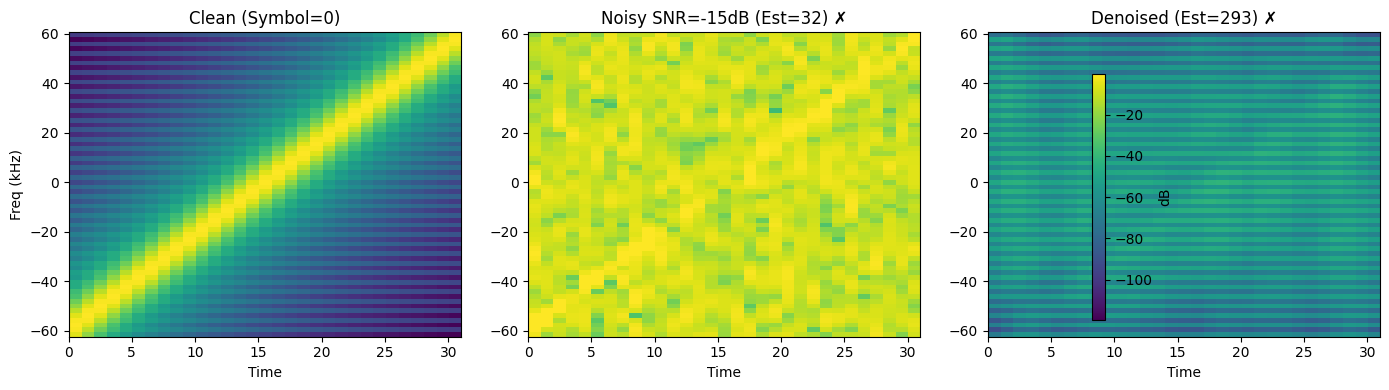

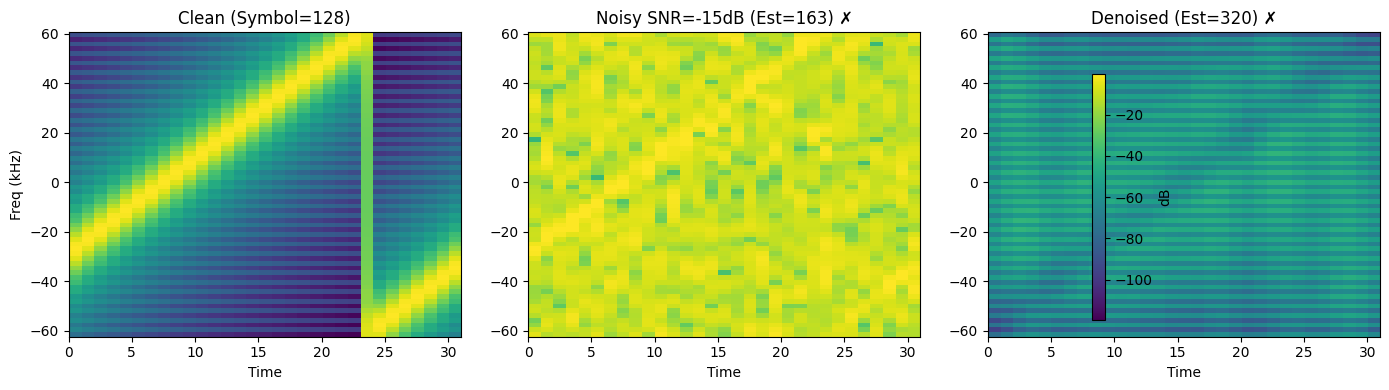

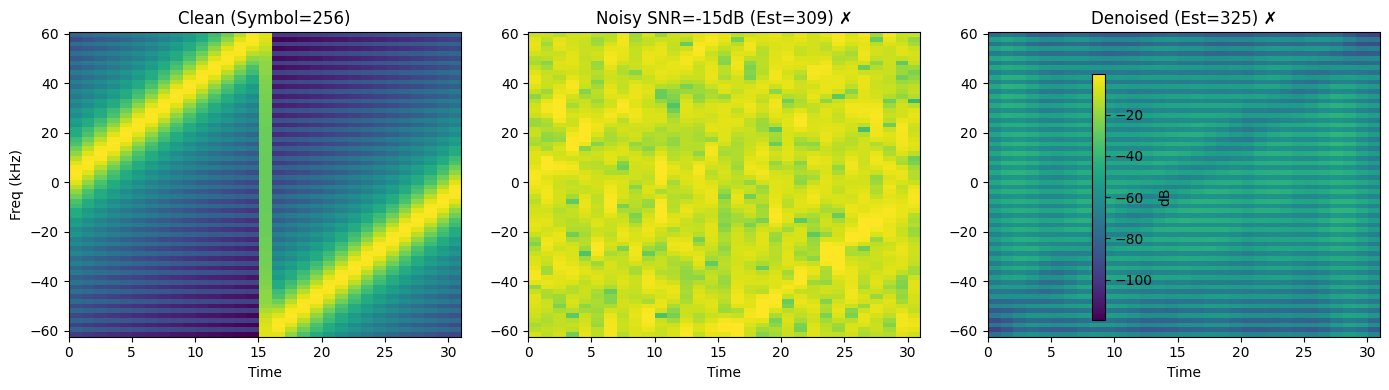

In [12]:
# ===== 시각화: 디노이징 결과 =====

def visualize_denoising(sym_idx=0, snr=-15):
    """클린/노이즈/디노이징 스펙트로그램 비교"""
    clean = clean_iq[sym_idx]
    noisy = lora.awgn_iq(clean, snr)
    
    mag_clean, f_crop, _ = stft_bw_crop(clean)
    mag_noisy, _, _ = stft_bw_crop(noisy)
    mag_denoised, _, _ = denoise_spectrogram(noisy, model, global_mean, global_std)
    
    est_noisy, _ = estimate_from_spectrogram(mag_noisy, f_crop)
    est_denoised, _ = estimate_from_spectrogram(mag_denoised, f_crop)
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    vmin, vmax = mag_clean.min(), mag_clean.max()
    extent = [0, mag_clean.shape[1], f_crop[0]/1000, f_crop[-1]/1000]
    
    axes[0].imshow(mag_clean, aspect='auto', origin='lower', cmap='viridis',
                   vmin=vmin, vmax=vmax, extent=extent)
    axes[0].set_title(f'Clean (Symbol={sym_idx})')
    axes[0].set_xlabel('Time'); axes[0].set_ylabel('Freq (kHz)')
    
    mark = '✓' if est_noisy == sym_idx else '✗'
    axes[1].imshow(mag_noisy, aspect='auto', origin='lower', cmap='viridis',
                   vmin=vmin, vmax=vmax, extent=extent)
    axes[1].set_title(f'Noisy SNR={snr}dB (Est={est_noisy}) {mark}')
    axes[1].set_xlabel('Time')
    
    mark = '✓' if est_denoised == sym_idx else '✗'
    im = axes[2].imshow(mag_denoised, aspect='auto', origin='lower', cmap='viridis',
                        vmin=vmin, vmax=vmax, extent=extent)
    axes[2].set_title(f'Denoised (Est={est_denoised}) {mark}')
    axes[2].set_xlabel('Time')
    
    plt.colorbar(im, ax=axes, label='dB', shrink=0.8)
    plt.tight_layout()
    plt.show()


print(f"\n📈 디노이징 시각화 ({NUM_LAYERS}층 BAM)")
for sym in [0, 128, 256]:
    visualize_denoising(sym_idx=sym, snr=-15)

/home/gwon9906/miniconda3/envs/ai/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


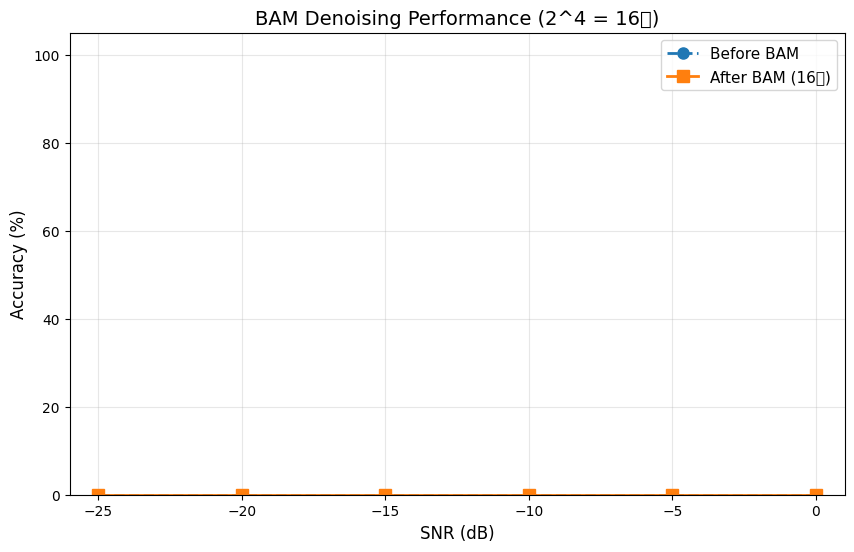


📊 SNR별 개선율:
  SNR   0dB: +0.0%
  SNR  -5dB: +0.0%
  SNR -10dB: +0.0%
  SNR -15dB: +0.0%
  SNR -20dB: +0.0%
  SNR -25dB: +0.0%


In [13]:
# ===== 성능 그래프 =====

snrs = sorted(results.keys(), reverse=True)
acc_before = [results[s]['before'] / results[s]['total'] * 100 for s in snrs]
acc_after = [results[s]['after'] / results[s]['total'] * 100 for s in snrs]

plt.figure(figsize=(10, 6))
plt.plot(snrs, acc_before, 'o--', label='Before BAM', linewidth=2, markersize=8)
plt.plot(snrs, acc_after, 's-', label=f'After BAM ({NUM_LAYERS}층)', linewidth=2, markersize=8)
plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title(f'BAM Denoising Performance (2^{int(np.log2(NUM_LAYERS))} = {NUM_LAYERS}층)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([min(snrs)-1, max(snrs)+1])
plt.ylim([0, 105])
plt.show()

# 개선율
print("\n📊 SNR별 개선율:")
for snr in snrs:
    diff = acc_after[snrs.index(snr)] - acc_before[snrs.index(snr)]
    print(f"  SNR {snr:>3}dB: {diff:+.1f}%")